# Assignment 02: Named Entity Recognition (NER) from a News Article

**Name:** Kiran Khatri
**Objective:** Apply Named Entity Recognition (NER) to identify and extract named entities (people, organizations, locations, dates, money, etc.) from an English news article using spaCy.

**Pipeline:**
1. Load the article text file
2. Run spaCy's NER model over the text
3. Extract each entity and its entity type
4. Export the results to a CSV file (`Entity`, `Entity_Type` columns)
5. Summarize entity counts by category
6. (Bonus) Visualize entities with displaCy and briefly compare two NER approaches


## 1. Install & Import Libraries

We use [spaCy](https://spacy.io/)'s `en_core_web_sm` pipeline, which includes a pretrained statistical NER model.

In [2]:
# Run this cell once if spaCy / the English model are not installed
#!pip install spacy
#!python -m spacy download en_core_web_sm

In [4]:
import spacy
from spacy import displacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline loaded:", nlp.pipe_names)


spaCy pipeline loaded: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 2. Load the News Article

The article was downloaded from a news source and saved as a plain text file: `article.txt`.


In [5]:
ARTICLE_PATH = "article.txt"

with open(ARTICLE_PATH, "r", encoding="utf-8") as f:
    article_text = f.read()

print(f"Article length: {len(article_text)} characters")
print("\n--- Preview ---\n")
print(article_text[:500], "...")


Article length: 2096 characters

--- Preview ---

Global Leaders Gather in Geneva to Discuss Climate Financing

Geneva, Switzerland - Representatives from more than sixty countries met in Geneva on Thursday to negotiate a new round of climate financing aimed at helping developing nations transition to renewable energy. The three-day summit, organized by the United Nations Environment Programme, brought together government ministers, business executives, and scientists to discuss funding mechanisms for solar and wind projects across Africa and S ...


## 3. Perform Named Entity Recognition

We pass the text through the spaCy pipeline. Recognized entities are available in `doc.ents`, each carrying a `.text` and a `.label_` (entity type).

In [6]:
doc = nlp(article_text)

for ent in doc.ents[:15]:
    print(f"{ent.text:<30} {ent.label_}")


Global Leaders Gather          ORG
Geneva                         GPE
Geneva                         GPE
Switzerland                    GPE
more than sixty                CARDINAL
Geneva                         GPE
Thursday                       DATE
three-day                      DATE
the United Nations Environment Programme ORG
Africa                         LOC
Southeast Asia                 LOC
Hello Kiran                    PERSON
Maria Chen                     PERSON
Pacific island                 LOC
one hundred billion dollars    MONEY


## 4. Extract Entities and Their Types

Common entity types produced by spaCy include:

| Label | Meaning |
|---|---|
| PERSON | People, including fictional |
| ORG | Companies, agencies, institutions |
| GPE | Countries, cities, states |
| DATE | Absolute or relative dates/periods |
| MONEY | Monetary values |
| CARDINAL / PERCENT | Numbers / percentages |
| EVENT | Named events (e.g. summits, wars) |
| NORP | Nationalities, religious/political groups |


In [7]:
records = [{"Entity": ent.text, "Entity_Type": ent.label_} for ent in doc.ents]
df = pd.DataFrame(records)
print(f"Total entities extracted: {len(df)}")
df.head(15)


Total entities extracted: 30


,Entity,Entity_Type
0,Global Leaders Gather,ORG
1,Geneva,GPE
2,Geneva,GPE
3,Switzerland,GPE
4,more than sixty,CARDINAL
5,Geneva,GPE
6,Thursday,DATE
7,three-day,DATE
8,the United Nations Environment Programme,ORG
9,Africa,LOC


## 5. Export to CSV

In [8]:
OUTPUT_CSV = "KiranKhatri_NER_01.csv"  # rename with your own name before submitting

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_CSV}")


Saved 30 rows to KiranKhatri_NER_01.csv


## 6. Summary of Entity Types Found

Entity_Type
GPE         11
DATE         5
ORG          4
LOC          3
CARDINAL     2
PERSON       2
MONEY        1
PERCENT      1
QUANTITY     1
Name: count, dtype: int64


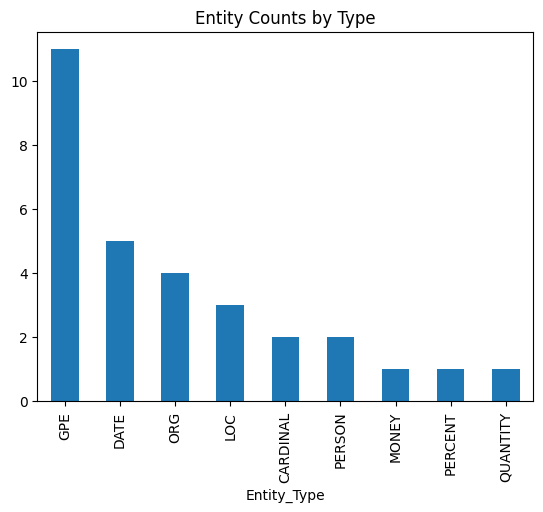

In [9]:
summary = df["Entity_Type"].value_counts()
print(summary)
summary.plot(kind="bar", title="Entity Counts by Type");


**Interpretation:** The bar chart and table above show how many entities of each type (e.g. `GPE`, `ORG`, `PERSON`, `DATE`, `MONEY`) were found in the article. This gives a quick sense of what the article is mostly "about" — for example, an article dominated by `GPE` and `ORG` entities is likely focused on geopolitics/organizations, while one dominated by `PERSON` entities is more people-centric.


## 7. Bonus: Visualize Entities with displaCy

`displacy.render` highlights each recognized entity directly in the original text, color-coded by type.


In [10]:
displacy.render(doc, style="ent", jupyter=True)


## 8. Bonus: Comparing Two NER Approaches

Below we compare spaCy's small pipeline (`en_core_web_sm`) against NLTK's NER, which relies on a different (older, rule/statistics hybrid) approach, to see how their outputs differ on the same text.


In [12]:
%pip install nltk

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 2.6 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [regex]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   -------------------- ------------------- 1/2 [nltk]
   ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import nltk

for pkg in ["punkt", "punkt_tab", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
            "maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(pkg, "->", e)


In [14]:
from nltk import word_tokenize, pos_tag, ne_chunk
from nltk.tree import Tree

def nltk_entities(text):
    chunks = ne_chunk(pos_tag(word_tokenize(text)))
    entities = []
    for chunk in chunks:
        if isinstance(chunk, Tree):
            entity_text = " ".join(token for token, pos in chunk.leaves())
            entities.append((entity_text, chunk.label()))
    return entities

nltk_ents = nltk_entities(article_text)
nltk_df = pd.DataFrame(nltk_ents, columns=["Entity", "Entity_Type"])
print(f"NLTK found {len(nltk_df)} entities vs spaCy's {len(df)} entities")
nltk_df.head(15)


NLTK found 22 entities vs spaCy's 30 entities


,Entity,Entity_Type
0,Global,PERSON
1,Leaders Gather,ORGANIZATION
2,Geneva,GPE
3,Discuss Climate Financing Geneva,PERSON
4,Switzerland,GPE
5,Geneva,GPE
6,United Nations,ORGANIZATION
7,Environment Programme,ORGANIZATION
8,Africa,GPE
9,Southeast Asia,LOCATION


**Discussion:** spaCy's `en_core_web_sm` typically recognizes a richer set of entity types (e.g. `DATE`, `MONEY`, `PERCENT`, `GPE` vs `ORG`/`LOCATION` distinctions) and tends to be more precise on modern text because it was trained on a broad, contemporary corpus (OntoNotes 5). NLTK's built-in chunker is a lighter-weight, older maximum-entropy model that only distinguishes a handful of coarse categories (`PERSON`, `ORGANIZATION`, `GPE`/`LOCATION`) and does not detect dates, money, or percentages at all. In practice, spaCy is generally preferred for production NER work, while NLTK is useful for lightweight or educational use cases.


## 9. Conclusion

This notebook loaded a news article, ran spaCy's Named Entity Recognition model over it, extracted every entity together with its type, exported the results to CSV (`Entity`, `Entity_Type`), summarized entity counts by category, visualized the entities inline with displaCy, and compared spaCy's output against NLTK's NER as a bonus exercise.
